In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.linear_model import Ridge
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import random, warnings
warnings.filterwarnings("ignore")

In [ ]:
# I did processing in Explor_Prepros notebook. The data is already cleaned, cyclical encoding done.
# The split is chronological, scaler fits on train only.

# I used naive baselines before creating the LSTM model to see if the LSTM model will be good or not.
# On Tetouan ds, LSTM lower score than Ridge. 
# Here I wanna test if LSTM works better on regime-switching data like steel factory energy.

In [13]:
# reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [14]:
# preprocessed data from the Regression notebook
df = pd.read_csv("../Regression/cleaned_data.csv")
df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,WeekStatus,Day_of_week_Monday,Day_of_week_Thursday,Day_of_week_Tuesday,Day_of_week_Wednesday,Load_Type_Maximum_Load,Load_Type_Medium_Load,NSM_sin,NSM_cos,month_sin,month_cos
0,3.17,2.95,0.0,0,1,0,0,0,0,0,0.065403,0.997859,0.5,0.866025
1,4.00,4.46,0.0,0,1,0,0,0,0,0,0.130526,0.991445,0.5,0.866025
2,3.24,3.28,0.0,0,1,0,0,0,0,0,0.195090,0.980785,0.5,0.866025
3,3.31,3.56,0.0,0,1,0,0,0,0,0,0.258819,0.965926,0.5,0.866025
4,3.82,4.50,0.0,0,1,0,0,0,0,0,0.321439,0.946930,0.5,0.866025


In [ ]:
# In this cell, I am gonna split the ds. The data is already preprocessed from Explor prepros notebook.
target = 'Usage_kWh'
continuous_columns = ['Lagging_Current_Reactive.Power_kVarh']
time_columns = ["NSM_sin", "NSM_cos","month_sin", "month_cos",'WeekStatus']

size = len(df)
splitter = int(size*0.80)
val_splitter = int(size * 0.90)

train_df = df.iloc[:splitter]
val_df = df.iloc[splitter:val_splitter]
test_df = df.iloc[val_splitter:]

print(train_df.shape, val_df.shape, test_df.shape)

(28032, 14) (3504, 14) (3504, 14)


In [ ]:
# Scaling the data, I dont need to scale the time columns
input_steps = 96    
next_steps = 4    

x_scaler = RobustScaler()
y_scaler= RobustScaler()

X_train = np.hstack([x_scaler.fit_transform(train_df[continuous_columns]), train_df[time_columns].values])
X_val= np.hstack([x_scaler.transform(val_df[continuous_columns]),val_df[time_columns].values])
X_test = np.hstack([x_scaler.transform(test_df[continuous_columns]),test_df[time_columns].values])

y_train = y_scaler.fit_transform(train_df[[target]])
y_val= y_scaler.transform(val_df[[target]])
y_test = y_scaler.transform(test_df[[target]])

In [ ]:

# I created window function same in keras notebook. 
def make_windows(X, y, input_steps, output_steps):
    Xw, yw = [], []
    for i in range(len(X)-input_steps - output_steps + 1):
        Xw.append(np.hstack([X[i:i + input_steps], y[i:i + input_steps]]))
        yw.append(y[i + input_steps:i + input_steps + output_steps])
    return np.stack(Xw), np.stack(yw)
    
def convert_original(values):
    return y_scaler.inverse_transform(values.reshape(-1,1)).ravel()

X_train_window, y_train_window = make_windows(X_train, y_train, input_steps, next_steps)
X_val_window, y_val_window = make_windows(X_val, y_val, input_steps, next_steps)
X_test_window, y_test_window = make_windows(X_test, y_test, input_steps, next_steps)

print(X_train_window.shape, y_train_window.shape)
print(X_val_window.shape, y_val_window.shape)
print(X_test_window.shape, y_test_window.shape)

(27933, 96, 7) (27933, 4, 1)
(3405, 96, 7) (3405, 4, 1)
(3405, 96, 7) (3405, 4, 1)


In [ ]:
# Here, before building the LSTM model, I wanna check baselines first

y_test_original = convert_original(y_test_window)
naive_scaled = np.tile(X_test_window[:, -1, -1:], (1, next_steps))
naive_predicted = convert_original(naive_scaled)


X_train_flat = X_train_window.reshape(len(X_train_window), -1)
X_test_flat = X_test_window.reshape(len(X_test_window), -1)
y_train_flat = y_train_window.reshape(len(y_train_window),-1)

ridge_model  = Ridge(alpha=1.0).fit(X_train_flat, y_train_flat)
ridge_predicted = convert_original(ridge_model.predict(X_test_flat))

baselines = {}
for name, prediction in [("Naive", naive_predicted), ("Ridge", ridge_predicted)]:

    baselines[name] = {"MAE": mean_absolute_error(y_test_original, prediction),
                       "RMSE": np.sqrt(mean_squared_error(y_test_original, prediction)),
                       "R2": r2_score(y_test_original, prediction)}

print(pd.DataFrame(baselines).T.round(4))

# I used QWEN for debugging. 
# for this ds,  Ridge gets not bad score.
# It seems that most of structures are learnable.
#  

          MAE     RMSE      R2
Naive  7.1995  16.5821  0.6611
Ridge  7.7358  11.8710  0.8263


### Build LSTM

In [19]:
def build_model(shape):
    inp = layers.Input(shape=shape)
    x = layers.Conv1D(32, 16, padding="causal", activation="relu")(inp)
    x = layers.LSTM(48, kernel_regularizer=regularizers.l2(0.0001))(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Dense(24, activation="relu")(x)
    x = layers.Dense(next_steps)(x)
    return tf.keras.Model(inp, x)

model = build_model(X_train_window.shape[1:])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 32)         │         3,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 48)             │        15,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,444 (79.86 KB)

 Trainable params: 20,444 (79.86 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1), loss=tf.keras.losses.LogCosh())

CallBacks = [EarlyStopping(monitor='val_loss', patience=6,min_delta=0.00001, restore_best_weights=True),
             ReduceLROnPlateau(monitor="val_loss",factor=0.5, patience=3,min_delta=0.00001)]

history = model.fit(X_train_window, y_train_window, validation_data=(X_val_window, y_val_window),
                    epochs=50, batch_size=128, shuffle=False, verbose=0, callbacks=CallBacks)

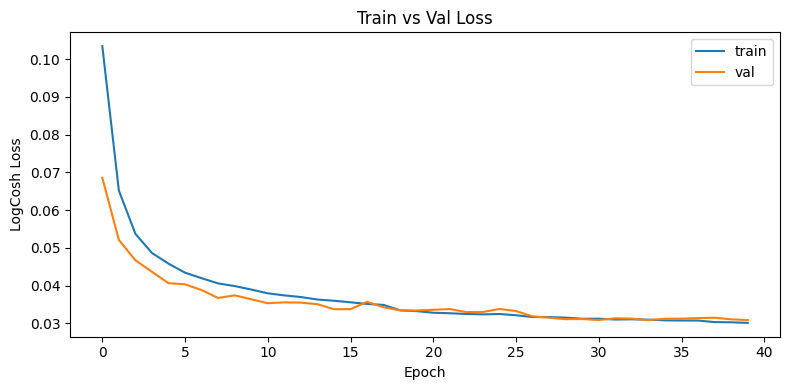

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel('LogCosh Loss')
plt.legend()
plt.title("Train vs Val Loss")
plt.tight_layout()
plt.show()
# No gap between train and val loss, no overfitting. 

### LSTM evaluation

In [22]:
# In this cell, I am gonna evaluate the LSTM model and compare it with baselines.
lstm_predicted = convert_original(model.predict(X_test_window, batch_size=256, verbose=0))

comparison = []
for name, basline in baselines.items():
    comparison.append({"model":name,'MAE':basline["MAE"], 'RMSE':basline["RMSE"], "R2":basline["R2"]})

comparison.append({"model":"LSTM","MAE":mean_absolute_error(y_test_original, lstm_predicted),
                                  'RMSE':np.sqrt(mean_squared_error(y_test_original, lstm_predicted)),
                                  'R2':r2_score(y_test_original, lstm_predicted)})

comparison=pd.DataFrame(comparison).round(2)
print(comparison)

   model   MAE   RMSE    R2
0  Naive  7.20  16.58  0.66
1  Ridge  7.74  11.87  0.83
2   LSTM  5.59  10.79  0.86


In [ ]:
# I used the same preprocessed data in the Regression notebook.
# For this ds, LSTM  gets better score than Ridge. 